In [25]:
import time

from pathlib import Path
from matplotlib import pyplot as plt

import numpy as np

import gwcs
from jwst import datamodels

from astropy import units as u
from astropy.coordinates import SkyCoord, SpectralCoord

In [26]:
n6791fits = list(Path('../ngc6791_cals').glob('*.fits'))
n6791dms = [datamodels.open(fn) for fn in n6791fits]

dm0 = n6791dms[0]
s = dm0.slits[42]
swcs = s.meta.wcs

# First lets explore the frames

In [27]:
worldcen = swcs.pixel_to_world(*[elem//2 for elem in s.data.shape[::-1]])
worldcenvals = swcs.pixel_to_world_values(*[elem//2 for elem in s.data.shape[::-1]])
worldcen, worldcenvals

([<SkyCoord (ICRS): (ra, dec) in deg
      (290.24522102, 37.7463692)>,
  <SpectralCoord 1.11941931 um>],
 (290.2452210185242, 37.746369203071225, 1.1194193093055287))

In [28]:
swcs.world_to_pixel(*worldcen), [elem//2 for elem in s.data.shape[::-1]]

([633.006086930726, 12.000466912518618], [633, 12])

In [29]:
{fnm:swcs.transform('world', fnm, *worldcenvals) for fnm in swcs.available_frames if fnm!='world'}

{'detector': (633.006086930726, 12.000466912518618),
 'sca': (1415.006086930726, 277.0004669125186),
 'gwa': (0.10562929762879003, 0.23839428034236607, 0.9654069704443271),
 'slit_frame': (-0.0002831839674044892,
  0.41542891861800024,
  1.119352949574615e-06),
 'wavecorr_frame': (-0.0002831839674044892,
  0.41542891861800024,
  1.1194193093055287e-06),
 'msa_frame': (0.018780595440636236,
  0.029702014673534484,
  1.1194193093055287e-06),
 'oteip': (0.05560921161393654,
  0.016978788236520805,
  1.1194193093055287e-06,
  1.1194193093055287e-06),
 'v2v3': (292.17830734557333, -402.4604447253775, 1.1194193093055287),
 'v2v3vacorr': (292.1773021561665, -402.4601428553228, 1.1194193093055287)}

# Now see how a spectrum maps onto the pixels

In [30]:
specwl = SpectralCoord(np.linspace(0.9*u.micron, 1.3*u.micron, 100))

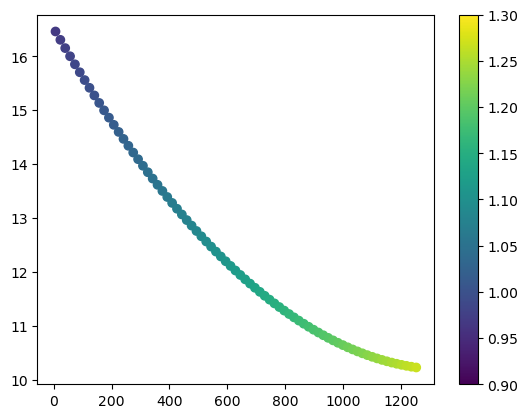

In [31]:
pixels = swcs.world_to_pixel(worldcen[0], specwl)
plt.scatter(pixels[0], pixels[1], c=specwl.value,vmin=specwl.value[0], vmax=specwl.value[-1])
plt.colorbar()

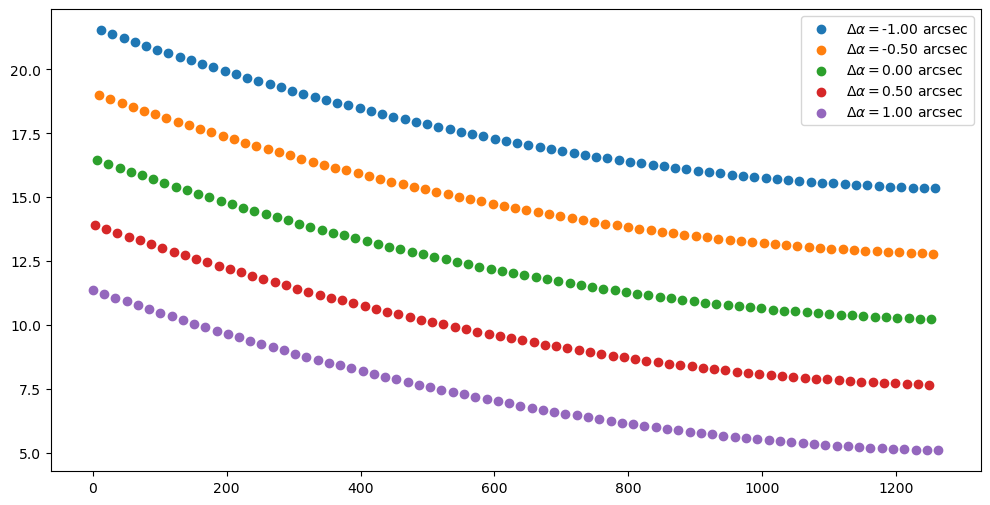

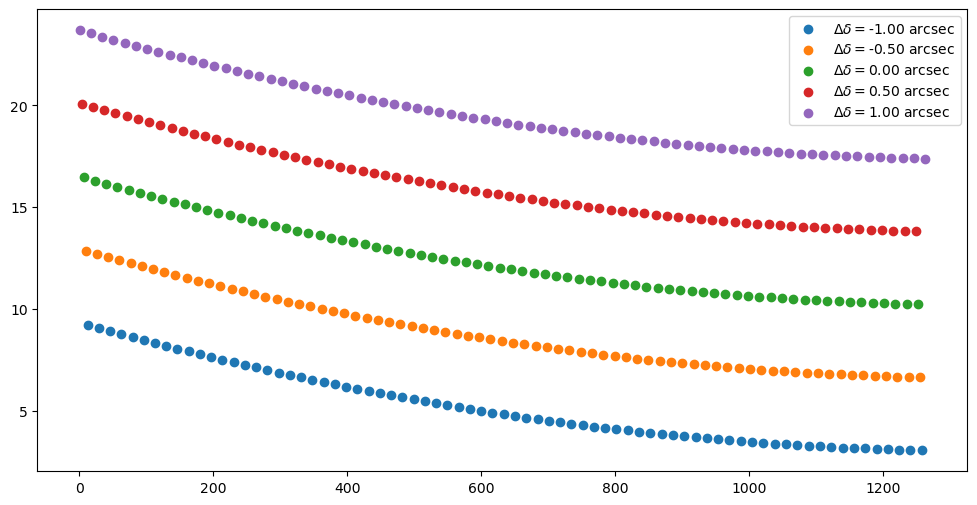

In [32]:
decoff = 0*u.arcsec
plt.figure(figsize=(12, 6))
for raoff in (np.linspace(-1, 1, 5))*u.arcsec:
    newsky = SkyCoord(raoff + worldcen[0].ra, decoff + worldcen[0].dec)
    pixels = swcs.world_to_pixel(newsky, specwl)
    plt.scatter(pixels[0], pixels[1], label=rf'$\Delta \alpha = ${raoff:.2f}')
plt.legend(loc=0)

raoff = 0*u.arcsec

plt.figure(figsize=(12, 6))
for decoff in (np.linspace(-1, 1, 5))*u.arcsec:
    newsky = SkyCoord(raoff + worldcen[0].ra, decoff + worldcen[0].dec)
    pixels = swcs.world_to_pixel(newsky, specwl)
    plt.scatter(pixels[0], pixels[1], label=rf'$\Delta \delta = ${decoff:.2f}')
plt.legend(loc=0)

(np.float64(28.991716677048316), <Angle 4.74747475 arcsec>, <Angle 0. arcsec>)

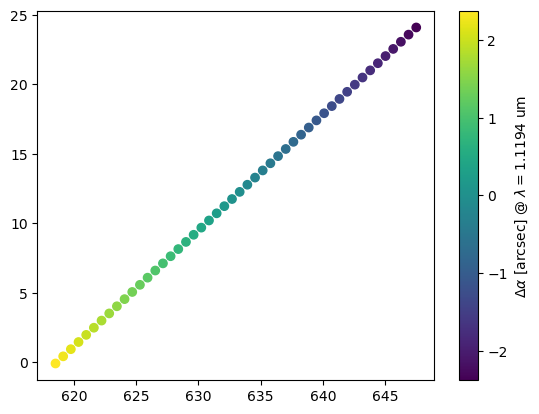

In [33]:
decoff = 0*u.arcsec
raoff = (np.linspace(-5, 5, 100))*u.arcsec
newsky = SkyCoord(raoff + worldcen[0].ra, decoff + worldcen[0].dec)
newwl = np.repeat(worldcen[1], len(newsky))
pixels = swcs.world_to_pixel(newsky, newwl)

plt.scatter(pixels[0], pixels[1], c=raoff.value)
plt.colorbar().set_label(r'$\Delta \alpha$ [arcsec] @ $\lambda = $' + f'{worldcen[1]:.4f}')

nanmsk = np.all(np.isfinite(pixels), axis=0)
np.ptp(pixels[0][nanmsk]), np.ptp(newsky[nanmsk].ra.to(u.arcsec)), np.ptp(newsky[nanmsk].dec.to(u.arcsec))

(np.float64(20.547711268703324), <Angle 0. arcsec>, <Angle 3.47347347 arcsec>)

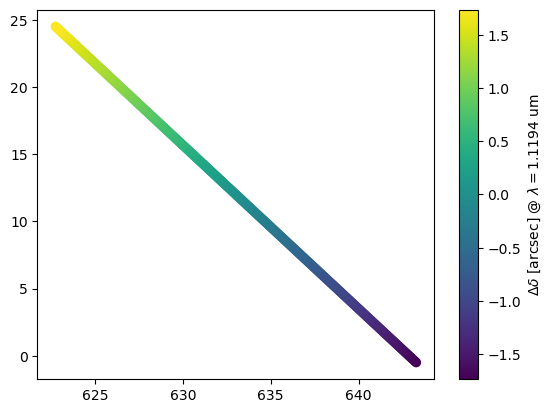

In [34]:
raoff = 0*u.arcsec
decoff = (np.linspace(-5, 5, 1000))*u.arcsec
newsky = SkyCoord(raoff + worldcen[0].ra, decoff + worldcen[0].dec)
newwl = np.repeat(worldcen[1], len(newsky))
pixels = swcs.world_to_pixel(newsky, newwl)

plt.scatter(pixels[0], pixels[1], c=decoff.value)
plt.colorbar().set_label(r'$\Delta \delta$ [arcsec] @ $\lambda = $' + f'{worldcen[1]:.4f}')

nanmsk = np.all(np.isfinite(pixels), axis=0)
np.ptp(pixels[0][nanmsk]), np.ptp(newsky[nanmsk].ra.to(u.arcsec)), np.ptp(newsky[nanmsk].dec.to(u.arcsec))

Text(0.5, 1.0, 'pixels @ [1.01941931 1.08941931 1.11941931 1.14941931 1.21941931] um')

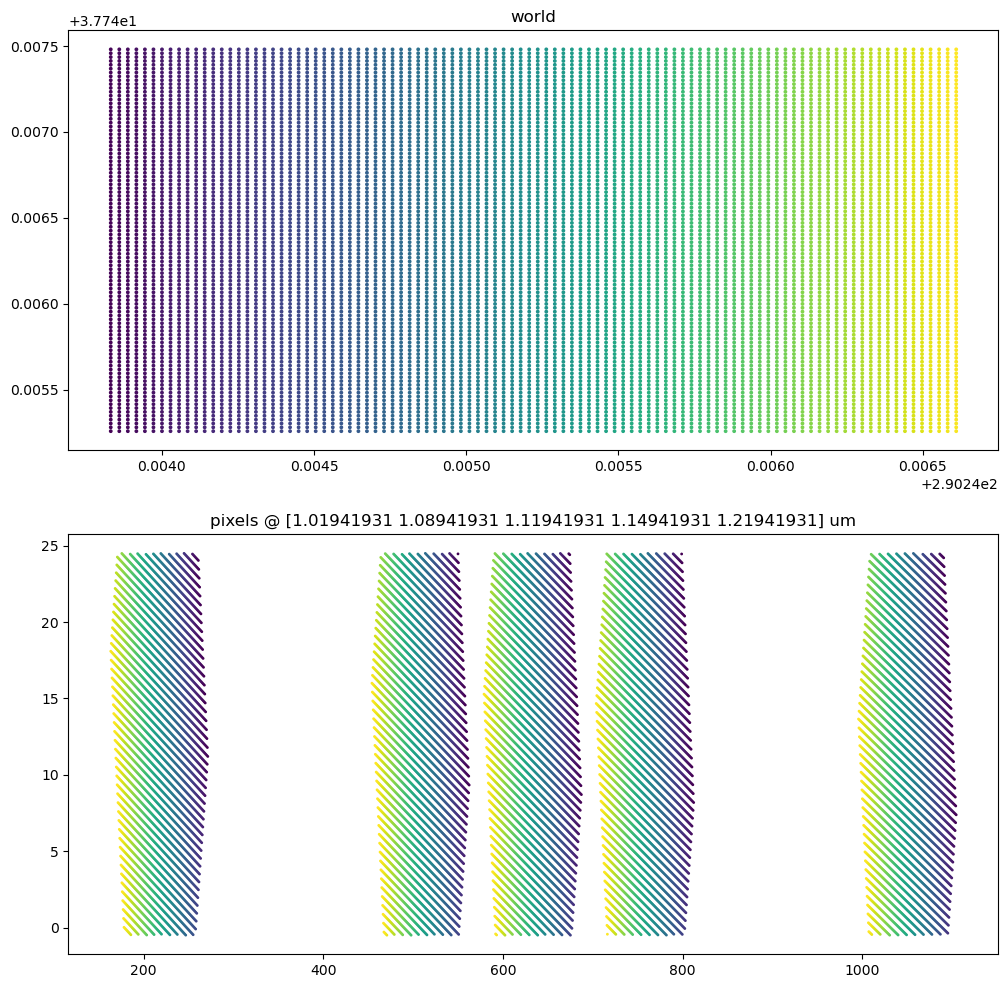

In [35]:
raoff, decoff = np.mgrid[-5:5:100j, -4:4:100j]*u.arcsec
newsky = SkyCoord(raoff + worldcen[0].ra, decoff + worldcen[0].dec)
newwl = np.repeat(worldcen[1], len(newsky))
pixels = swcs.world_to_pixel(newsky, newwl)

worldcens = worldcen[1] + [-.1, -0.03, 0, 0.03, .1]*u.micron

fig, (ax1, ax2) = plt.subplots(2,1, figsize=(12, 12))

order = np.linspace(0, 1, pixels[0].size)

ax1.scatter(newsky.ra.deg, newsky.dec.deg, c=order.reshape(newsky.ra.shape), vmin=0, vmax=1,s=3)

for w in worldcens:
    pixels = swcs.world_to_pixel(newsky, SpectralCoord(w))
    ax2.scatter(pixels[0], pixels[1], c=order.reshape(pixels[0].shape), vmin=0, vmax=1,s=1)

ax1.set_title('world')
ax2.set_title(f'pixels @ {worldcens}')

# Now examine the slit frame

In [36]:
worldcens = worldcen[1] + [-.1, -0.03, 0, 0.03, .1]*u.micron

w2 = swcs.transform('world', 'slit_frame', newsky.ra, newsky.dec, worldcens[2])
w1 = swcs.transform('world', 'slit_frame', newsky.ra, newsky.dec, worldcens[1])

np.all((np.array(w2[:2]) == np.array(w1[:2])))

np.True_

So there is no wavelength dependence in the slitcoords for this frame

Text(0.5, 1.0, 'slit @ 1.1194193093055287 um')

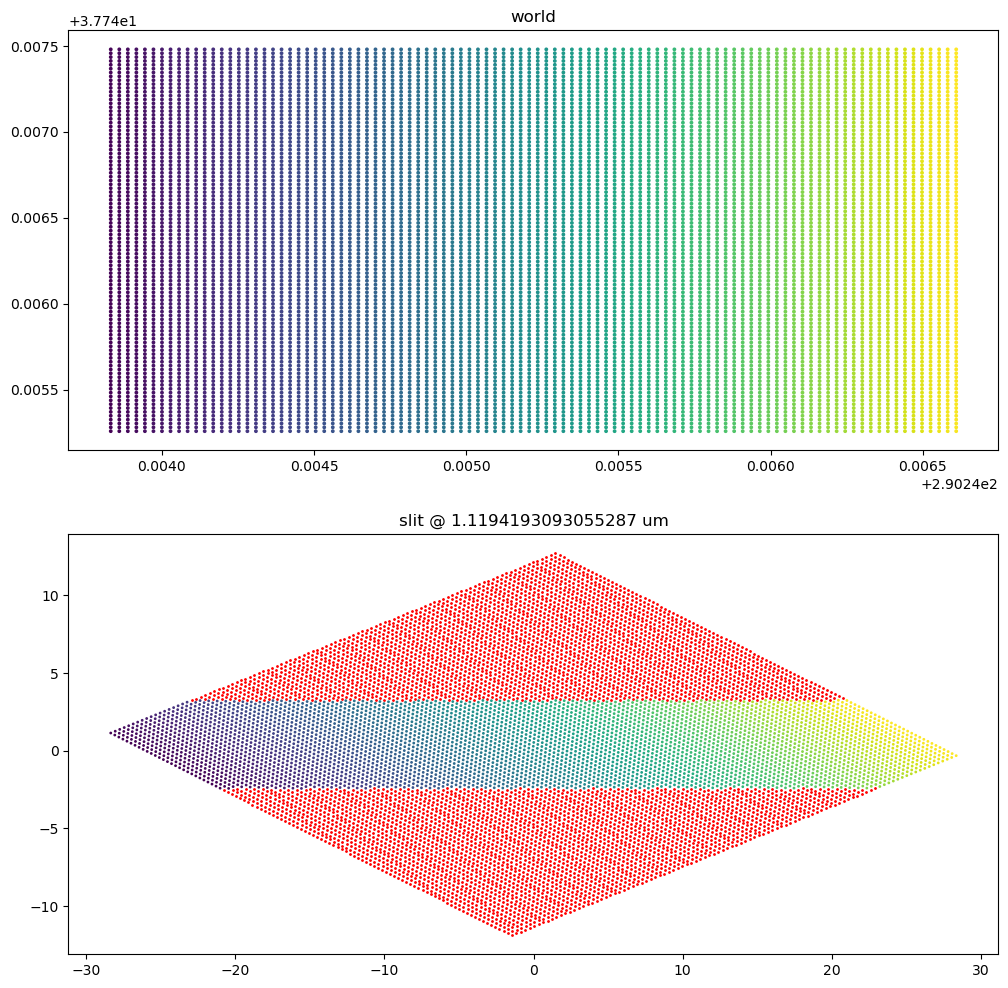

In [37]:
raoff, decoff = np.mgrid[-5:5:100j, -4:4:100j]*u.arcsec
newsky = SkyCoord(raoff + worldcen[0].ra, decoff + worldcen[0].dec)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

order = np.linspace(0, 1, pixels[0].size)

ax1.scatter(newsky.ra.deg, newsky.dec.deg, c=order.reshape(newsky.ra.shape), vmin=0, vmax=1,s=3)

w = worldcen[1]

slit = swcs.transform('world', 'slit_frame', newsky.ra, newsky.dec, w)

# this flags the off-detector pixels
pixels = swcs.world_to_pixel(newsky, w)
nanmsk = np.all(np.isfinite(pixels), axis=0)

ax2.scatter(slit[0][~nanmsk], slit[1][~nanmsk], c='r', s=1)
ax2.scatter(slit[0][nanmsk], slit[1][nanmsk], c=order.reshape(slit[0].shape)[nanmsk], vmin=0, vmax=1,s=1)

ax1.set_title('world')
ax2.set_title(f'slit @ {w}')

Text(0.5, 1.0, 'slitoff @ 1.2694193093055286 um')

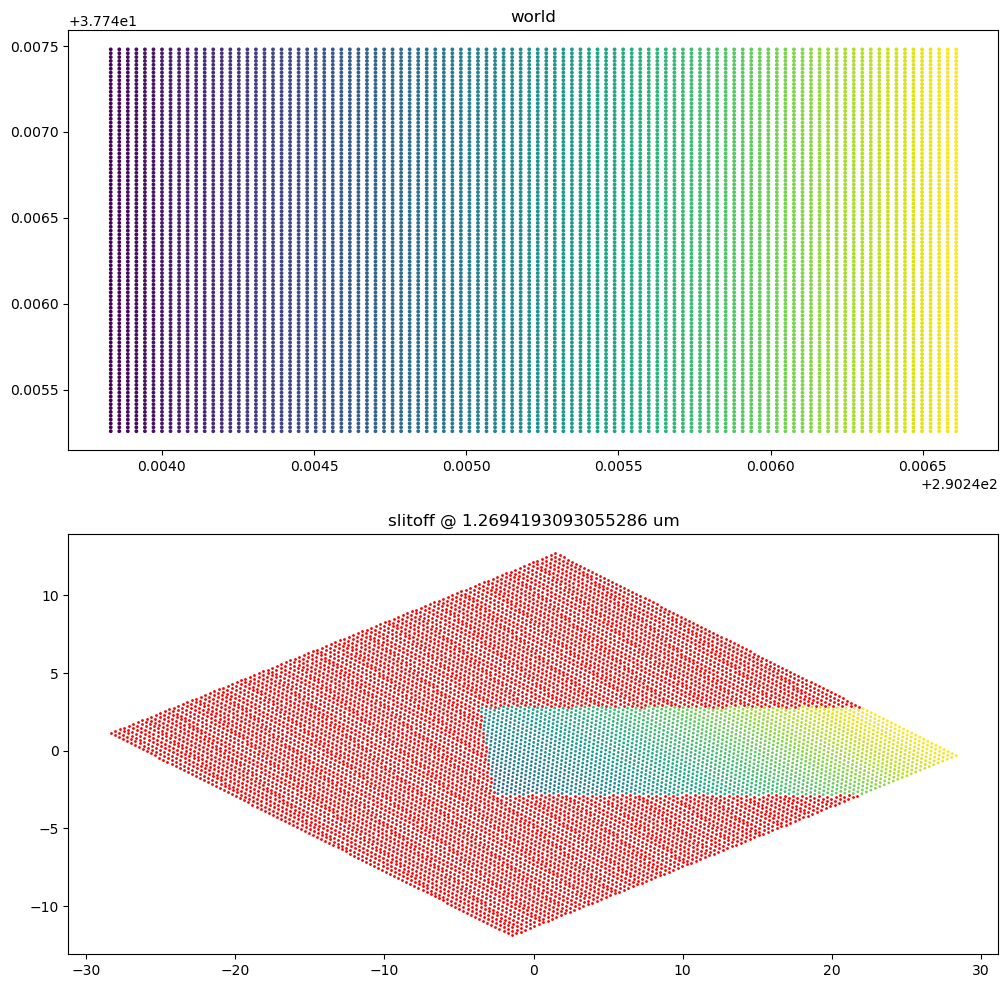

In [38]:
raoff, decoff = np.mgrid[-5:5:100j, -4:4:100j]*u.arcsec
newsky = SkyCoord(raoff + worldcen[0].ra, decoff + worldcen[0].dec)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

order = np.linspace(0, 1, pixels[0].size)

ax1.scatter(newsky.ra.deg, newsky.dec.deg, c=order.reshape(newsky.ra.shape), vmin=0, vmax=1,s=3)

# This is the difference vs the last one - a spectral offset
w = SpectralCoord(worldcen[1] + 0.15*u.micron)

slitoff = swcs.transform('world', 'slit_frame', newsky.ra, newsky.dec, w)

# this flags the off-detector pixels
pixels = swcs.world_to_pixel(newsky, w)
nanmsk = np.all(np.isfinite(pixels), axis=0)

ax2.scatter(slitoff[0][~nanmsk], slitoff[1][~nanmsk], c='r', s=1)
ax2.scatter(slitoff[0][nanmsk], slitoff[1][nanmsk], c=order.reshape(slitoff[0].shape)[nanmsk], vmin=0, vmax=1,s=1)

ax1.set_title('world')
ax2.set_title(f'slitoff @ {w}')

So there is an effect where you fall off the detector (as expected)

# Now compare slit and wavecorr frames

Text(0.5, 1.0, 'wavecorr @ 1.1194193093055287 um')

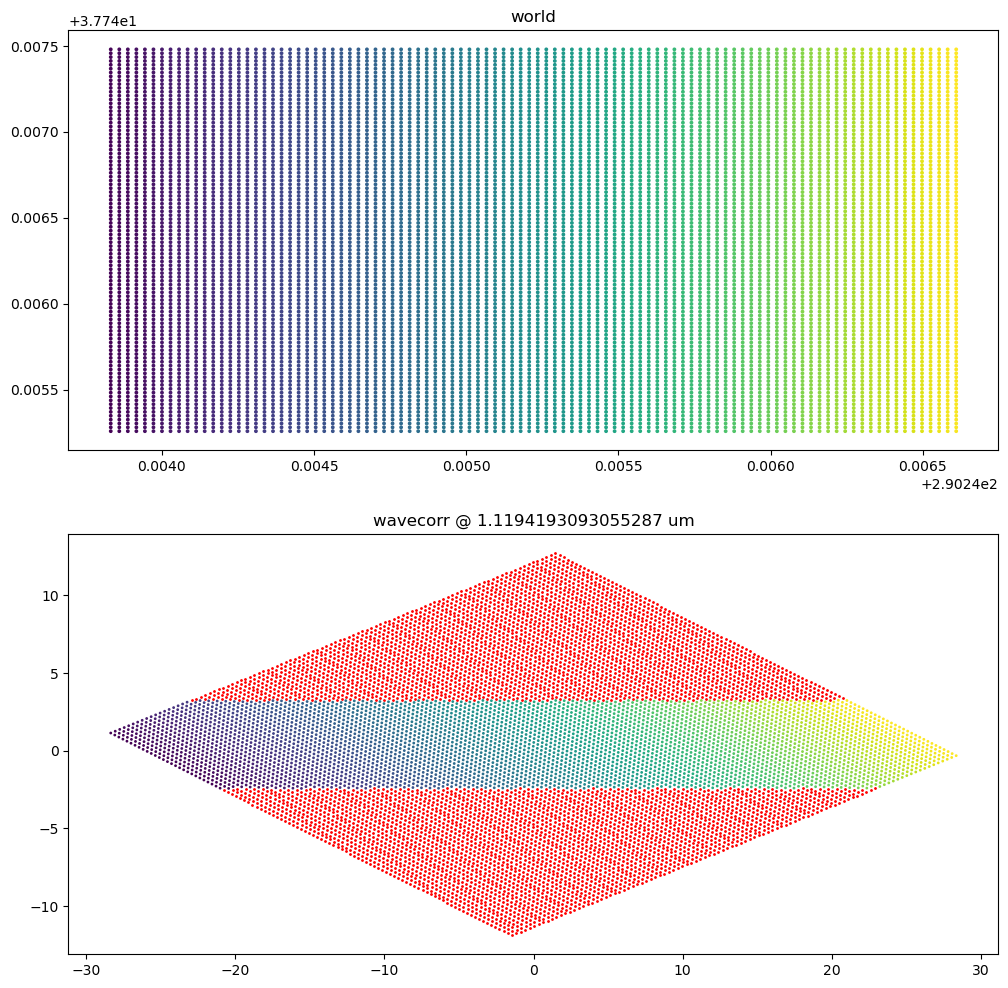

In [39]:
raoff, decoff = np.mgrid[-5:5:100j, -4:4:100j]*u.arcsec
newsky = SkyCoord(raoff + worldcen[0].ra, decoff + worldcen[0].dec)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

order = np.linspace(0, 1, pixels[0].size)

ax1.scatter(newsky.ra.deg, newsky.dec.deg, c=order.reshape(newsky.ra.shape), vmin=0, vmax=1,s=3)

w = worldcen[1]

wcorr = swcs.transform('world', 'wavecorr_frame', newsky.ra, newsky.dec, w)

# this flags the off-detector pixels
pixels = swcs.world_to_pixel(newsky, w)
nanmsk = np.all(np.isfinite(pixels), axis=0)

ax2.scatter(wcorr[0][~nanmsk], wcorr[1][~nanmsk], c='r', s=1)
ax2.scatter(wcorr[0][nanmsk], wcorr[1][nanmsk], c=order.reshape(wcorr[0].shape)[nanmsk], vmin=0, vmax=1,s=1)

ax1.set_title('world')
ax2.set_title(f'wavecorr @ {w}')

In [40]:
np.all(np.array(wcorr[:2]) == np.array(slit[:2]))

np.True_

No spatial variation, which is reasonable since it's a wavecorr.  What if we vary the wavelength?

In [41]:
specwl = SpectralCoord(np.linspace(0.9*u.micron, 1.3*u.micron, 100))
x, y, wl = swcs.transform('world', 'wavecorr_frame', worldcen[0].ra, worldcen[0].dec, specwl)

np.all(x==x[0]), np.all(y==y[0]), np.all(specwl.to(u.m).value == wl)

(np.True_, np.True_, np.True_)

As expected no slitpos variation, and the wavelength goes straight to the wavecorr.

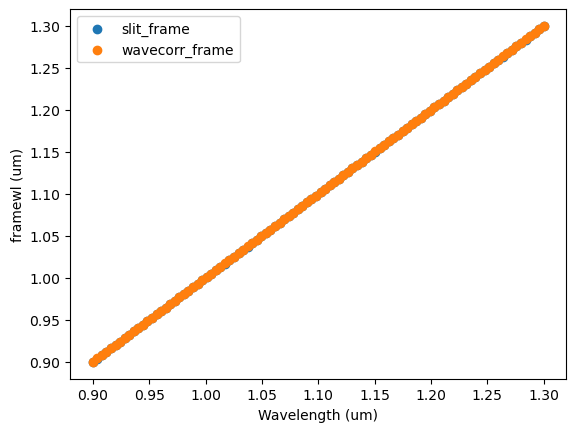

In [43]:
xs, ys, wls = swcs.transform('world', 'slit_frame', worldcen[0].ra, worldcen[0].dec, specwl)

plt.scatter(specwl.to(u.um).value, (wls*u.m).to(u.um), label='slit_frame')
plt.scatter(specwl.to(u.um).value, (wl*u.m).to(u.um), label='wavecorr_frame')
plt.xlabel('Wavelength (um)')
plt.ylabel('framewl (um)')
plt.legend()

Text(0, 0.5, 'slit_frame - wavecorr_frame (um)')

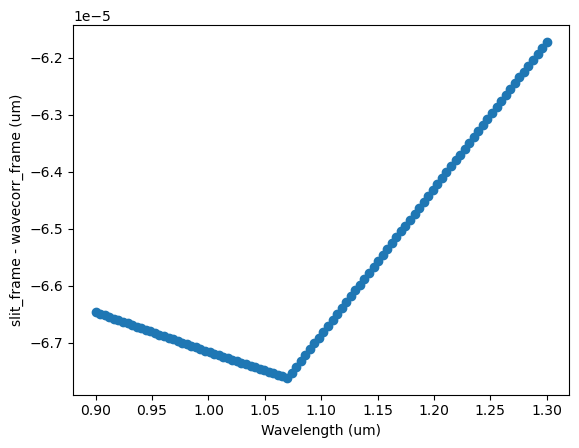

In [44]:
xs, ys, wls = swcs.transform('world', 'slit_frame', worldcen[0].ra, worldcen[0].dec, specwl)

plt.scatter(specwl.to(u.um).value, ((wls - wl)*u.m).to(u.um))

plt.xlabel('Wavelength (um)')
plt.ylabel('slit_frame - wavecorr_frame (um)')

Text(0, 0.5, '1 - slit_frame / wavecorr_frame')

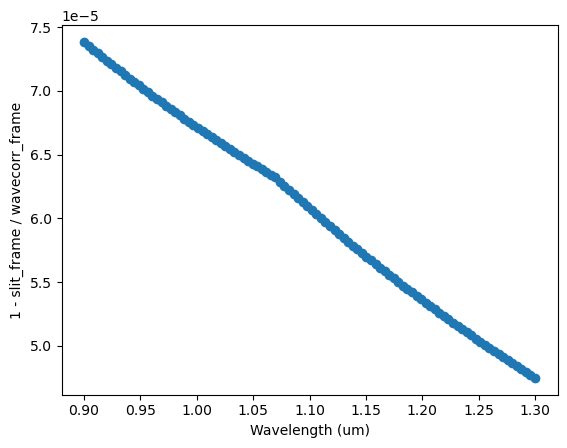

In [45]:
xs, ys, wls = swcs.transform('world', 'slit_frame', worldcen[0].ra, worldcen[0].dec, specwl)

plt.scatter(specwl.to(u.um).value, 1 - wls / wl)

plt.xlabel('Wavelength (um)')
plt.ylabel('1 - slit_frame / wavecorr_frame')

In [46]:
raoff = 0.1*u.arcsec
decoff = 0*u.arcsec
newsky = SkyCoord(raoff + worldcen[0].ra, decoff + worldcen[0].dec)

x1, y1, wl1 = swcs.transform('world', 'slit_frame', worldcen[0].ra, worldcen[0].dec, specwl)
x2, y2, wl2 = swcs.transform('world', 'slit_frame', newsky.ra, newsky.dec, specwl)

np.all(wl1 == wl2)

np.True_

So its the same shift regardless of the location.  Which probably makes sense since it's supposed to depend on the slit position. But why the kink?

This makes a wcs same as before but with the wavecorr excised

In [47]:
nowavecorr = swcs.pipeline.copy()
del nowavecorr[3]
nswcs = gwcs.WCS(nowavecorr)

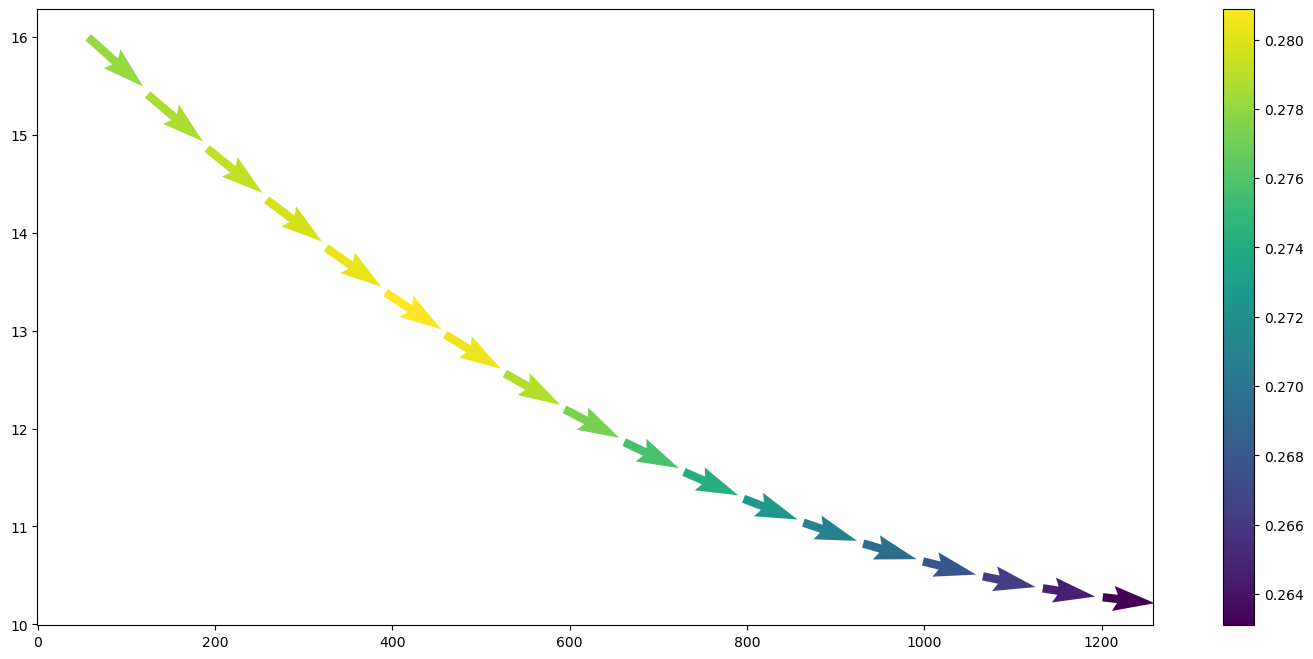

In [48]:
nowavecorr = swcs.pipeline.copy()
del nowavecorr[3]
nswcs = gwcs.WCS(nowavecorr)

subwl = specwl[::4]
x1, y1 = swcs.world_to_pixel(worldcen[0], subwl)
x2, y2 = nswcs.world_to_pixel(worldcen[0], subwl)
plt.figure(figsize=(18, 8))
plt.quiver(x1, y1, x2-x1, 100*(y2-y1), np.hypot(x2-x1, y2-y1))
plt.colorbar()

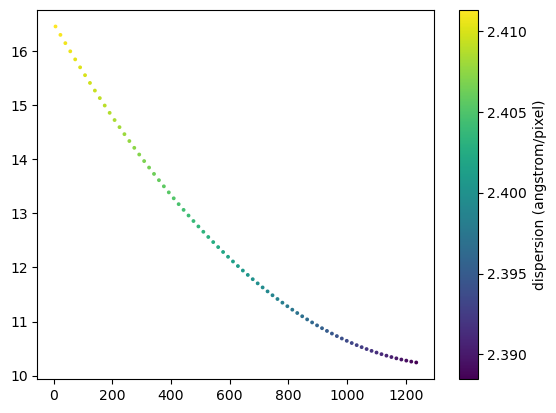

In [49]:
x, y = swcs.world_to_pixel(worldcen[0], specwl)
dx = x[1:] - x[:-1]
dy = y[1:] - y[:-1]
disp = np.diff(specwl)/(np.hypot(dx, dy)*u.pixel)
plt.scatter(x[:-1], y[:-1], c=disp.to(u.angstrom/u.pixel).value, s=3)
plt.colorbar().set_label('dispersion (angstrom/pixel)')

That just makes the kink all the more myterious.  Shouldn't it be proportional to dispersion?

Aha.  Reading https://jwst-pipeline.readthedocs.io/en/stable/jwst/wavecorr/description.html#nirspec-mos makes it clearer that the offset includes both the dispersion *and* the amount of offset at a given wavelength, which comes from the PSF.  So the story is consistent after all in that it would require PSF calcs to get it right anyway.

So probably for modeling the right thing to do is to use a non-wavecorr transform, and have the PSF instead carry the shift information.

# Pixel-> World

Understand better where the "center" is

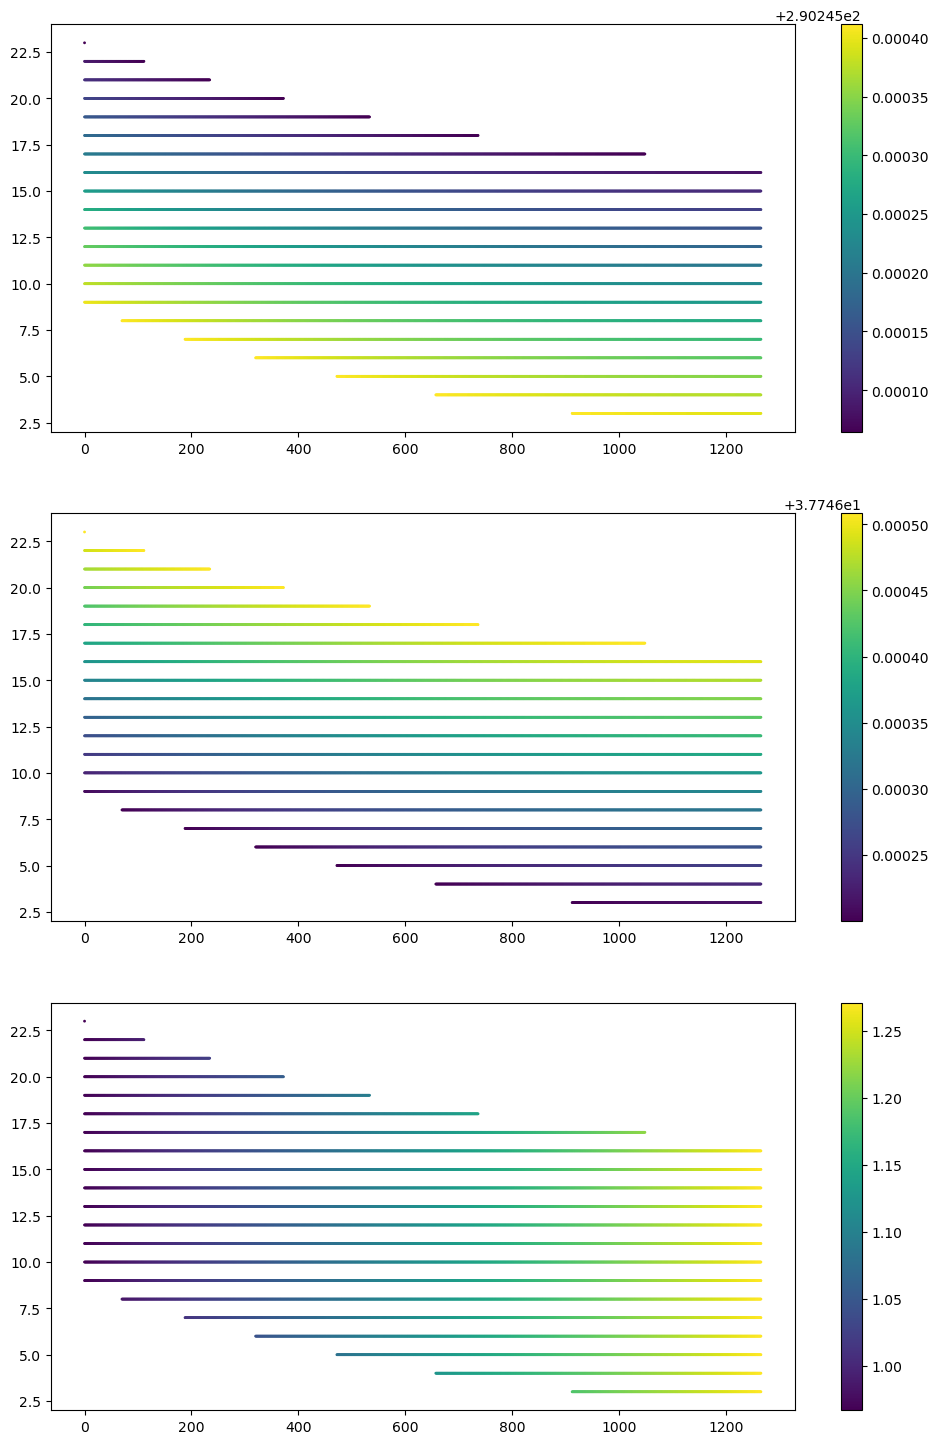

In [50]:
y, x = np.indices(s.data.shape)
wval = swcs.pixel_to_world_values(x, y)

fig, axs = plt.subplots(3, 1, figsize=(12, 18))

for i, ax in enumerate(axs):
    sc = ax.scatter(x, y, c=wval[i], s=1)
    plt.colorbar(sc, ax=ax)

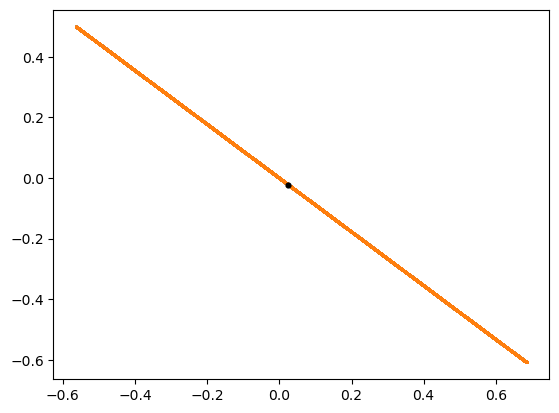

In [69]:
y, x = np.indices(s.data.shape)
wval = swcs.pixel_to_world_values(x, y)
nwval = nswcs.pixel_to_world_values(x, y)

plt.scatter((nwval[0] * u.deg- worldcen[0].ra).to(u.arcsec).value, (nwval[1] * u.deg - worldcen[0].dec).to(u.arcsec).value, s=1)
plt.scatter((wval[0] * u.deg- worldcen[0].ra).to(u.arcsec).value, (wval[1] * u.deg - worldcen[0].dec).to(u.arcsec).value, s=1)

plt.scatter([(s.source_ra*u.deg- worldcen[0].ra).to(u.arcsec).value], [(s.source_dec * u.deg - worldcen[0].dec).to(u.arcsec).value], s=12, c='k')

fig = plt.gcf()

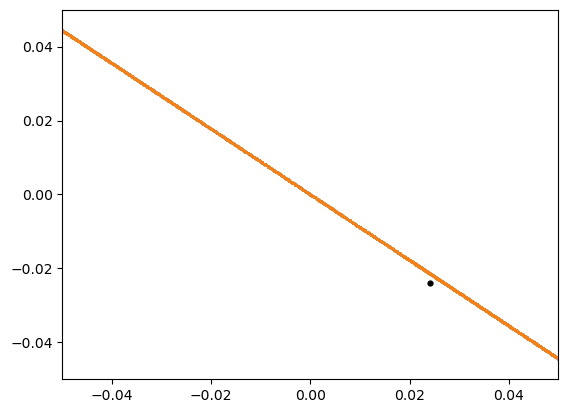

In [ ]:
fig.axes[0].set_xlim(-.05, .05)
fig.axes[0].set_ylim(-.05, .05)
fig

In [81]:
np.nanmin(SkyCoord(wval[0]<<u.deg, wval[1]<<u.deg).separation(SkyCoord(s.source_ra<<u.deg, s.source_dec<<u.deg))).arcsec

np.float64(0.0016948644429956325)

In [60]:
{k:v for k,v in s.items() if 'meta' not in k}

{'barshadow': array([[1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.],
        ...,
        [1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.]], shape=(25, 1266), dtype='>f4'),
 'barshadow_corrected': False,
 'cal_logs.assign_wcs': ['2025-12-23T01:55:43.285 - stpipe.step - INFO - Step assign_wcs running with args (<ImageModel(2048, 2048) from jw02609010001_03101_00001_nrs1_rate.fits>,).', '2025-12-23T01:55:43.428 - jwst.assign_wcs.nirspec - INFO - Retrieving open MSA slitlets for msa_metadata_id = 1 and dither_index = 1', '2025-12-23T01:55:43.551 - jwst.assign_wcs.nirspec - INFO - gwa_ytilt is 0.1332586 deg', '2025-12-23T01:55:43.551 - jwst.assign_wcs.nirspec - INFO - gwa_xtilt is 0.359196037 deg', '2025-12-23T01:55:43.551 - jwst.assign_wcs.nirspec - INFO - theta_y correction: 0.001646483256736436 deg', '2025-12-23T01:55:43.552 - jwst.assign_wcs.nirspec - INFO - theta_x c

In [80]:
(s.source_xpos * .2, s.source_ypos* .46)

(0.020000004768371583, 0.1637600028514862)

So this means every pixel maps to an RA/DEC that is the *source* position in the dispersion direction, not the slit center?

In [83]:
swcs.pipeline

[Step(frame=detector, transform=dms2sca),
 Step(frame=sca, transform=det2gwa),
 Step(frame=gwa, transform=gwa2slit),
 Step(frame=slit_frame, transform=CompoundModel),
 Step(frame=wavecorr_frame, transform=slit2msa),
 Step(frame=msa_frame, transform=msa2oteip),
 Step(frame=oteip, transform=oteip2v23),
 Step(frame=v2v3, transform=va_corr),
 Step(frame=v2v3vacorr, transform=v2v3_to_sky),
 Step(frame=world, transform=None)]

In [96]:
m = swcs.pipeline[0]
for i, m in enumerate(swcs.pipeline):
    print(i, m)
    print(m.transform)
    print('*'*50)

0 detector	 dms2sca
Model: CompoundModel
Name: dms2sca
Inputs: ('x0', 'x1')
Outputs: ('x', 'y')
Model set size: 1
Expression: [0] & [1] | (([2] & [3] | [4]) & [5] fix_inputs [6]) | [7]
Components: 
    [0]: <Shift(offset=782.)>

    [1]: <Shift(offset=265.)>

    [2]: <Shift(offset=0.)>

    [3]: <Shift(offset=0.)>

    [4]: <Identity(2)>

    [5]: <Identity(1)>

    [6]: {'name': 56}

    [7]: <Mapping((0, 1))>
Parameters:
    offset_0 offset_1 offset_2 offset_3
    -------- -------- -------- --------
       782.0    265.0      0.0      0.0
**************************************************
1 sca	 det2gwa
Model: CompoundModel
Name: det2gwa
Inputs: ('x', 'y')
Outputs: ('angle1', 'angle2', 'angle3')
Model set size: 1
Expression: (([0] | [1] & [2] | [3] | [4] & [5] | [6] | [7] & [8] | [9] | [10] & [11] | [12] | [13]) & [14] | [15] fix_inputs [16]) | [17]
Components: 
    [0]: <AffineTransformation2D(matrix=[[0.000018, 0.      ], [0.      , 0.000018]], translation=[0., 0.], name='fpa_affi